## Q6 — Which country has produced the most successful tennis players?

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load
IN_DIR = "cleaned_data"

event = pd.read_parquet(f'{IN_DIR}/event.parquet')
home = pd.read_parquet(f'{IN_DIR}/home_team.parquet')
away = pd.read_parquet(f'{IN_DIR}/away_team.parquet')

In [3]:
# "Successful" is ambiguous -- defined here primarily as total match wins
# attributed to players from that country (same win-attribution logic as
# Q3), with wins-per-player reported alongside as an average recorded wins per player view.
# country is missing on only 4/12,389 home rows and 2/11,690 away rows
#  -- no extra cleaning needed here beyond Q3's existing logic.
completed = event.loc[(event['winner_code'].notna()) & (event['score_ready']), ['match_id', 'winner_code']]
home_wins = (completed[completed['winner_code'] == 1]
             .merge(home[['match_id', 'player_id', 'country']], on='match_id', how='left'))
away_wins = (completed[completed['winner_code'] == 2]
             .merge(away[['match_id', 'player_id', 'country']], on='match_id', how='left'))
all_wins = pd.concat([home_wins, away_wins], ignore_index=True).dropna(subset=['player_id', 'country'])

country_wins = all_wins.groupby('country').size().rename('total_wins').sort_values(ascending=False)
print(f"Most successful country by total wins: {country_wins.index[0]} ({country_wins.iloc[0]} wins)\n")
print(country_wins.head(10))

player_n_country_h = home_wins.groupby('player_id')['country'].nunique()
noise_player_h = player_n_country_h[player_n_country_h > 1]
noise_player_h

player_n_country_a = away_wins.groupby('player_id')['country'].nunique()
noise_player_a = player_n_country_a[player_n_country_a > 1]
noise_player_a


Most successful country by total wins: France (986 wins)

country
France            986
Italy             933
USA               909
Russia            623
Argentina         547
Germany           527
Japan             521
Spain             477
Australia         434
United Kingdom    358
Name: total_wins, dtype: int64


player_id
158688.0    2
Name: country, dtype: int64

In [4]:
# secondary view: wins per player (min 50 players from that country, to
# avoid small-sample noise)
allp = (pd.concat([home[['player_id', 'country']], away[['player_id', 'country']]])
        .dropna().drop_duplicates('player_id'))
players_per_country = allp.groupby('country').size().rename('n_players')
combo = pd.concat([country_wins, players_per_country], axis=1).dropna()
combo['wins_per_player'] = (combo['total_wins'] / combo['n_players']).round(2)
combo = combo[combo['n_players'] >= 50].sort_values('wins_per_player', ascending=False)
print("\nWins per player (min. 50 players from that country):")
print(combo.head(5))


Wins per player (min. 50 players from that country):
                total_wins  n_players  wins_per_player
country                                               
Argentina            547.0         98             5.58
Brazil               290.0         58             5.00
France               986.0        202             4.88
Spain                477.0         98             4.87
Czech Republic       343.0         71             4.83


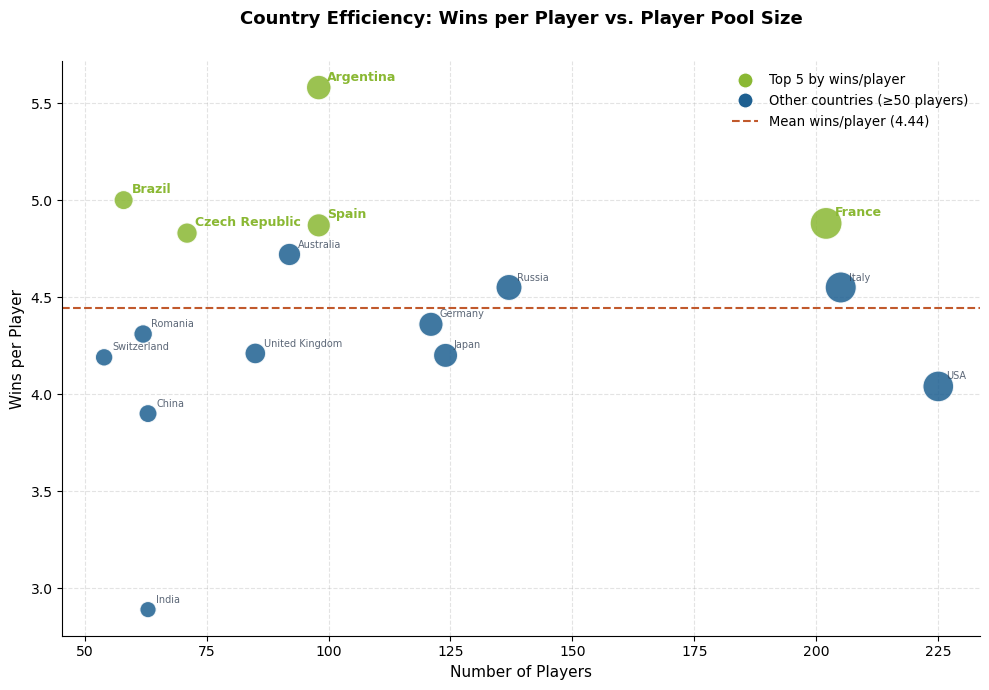

In [5]:
from matplotlib.lines import Line2D

TENNIS_BLUE = '#1E6091'
TENNIS_GREEN = '#8AB833'
CLAY_TERRACOTTA = '#C1592C'

fig, ax = plt.subplots(figsize=(10, 7))

sizes = 50 + (combo['total_wins'] / combo['total_wins'].max()) * 480
top5 = set(combo.head(5).index)
total_top_10 = country_wins.head(10)
colors = [TENNIS_GREEN if c in top5  else TENNIS_BLUE for c in combo.index]

ax.scatter(
    combo['n_players'],
    combo['wins_per_player'],
    s=sizes,
    c=colors,
    alpha=0.85,
    edgecolors='white',
    linewidths=0.9,
    zorder=3,
)

for country, row in combo.iterrows():
    is_top = country in top5
    ax.annotate(
        str(country),
        (row['n_players'], row['wins_per_player']),
        textcoords='offset points',
        xytext=(6, 5),
        fontsize=9 if is_top else 7,
        fontweight='bold' if is_top else 'normal',
        color=TENNIS_GREEN if is_top else '#334155',
        alpha=1.0 if is_top else 0.8,
    )

mean_wpp = float(combo['wins_per_player'].mean())
ax.axhline(mean_wpp, color=CLAY_TERRACOTTA, linestyle='--', linewidth=1.5, zorder=2)

ax.set_xlabel('Number of Players', fontsize=11)
ax.set_ylabel('Wins per Player', fontsize=11)
ax.set_title(
    'Country Efficiency: Wins per Player vs. Player Pool Size\n',
    fontsize=13, fontweight='bold', pad=12,
)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(True, linestyle='--', alpha=0.35, zorder=0)
ax.set_axisbelow(True)

legend_elems = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=TENNIS_GREEN,
           markersize=11, label='Top 5 by wins/player'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=TENNIS_BLUE,
           markersize=11, label='Other countries (≥50 players)'),
    Line2D([0], [0], color=CLAY_TERRACOTTA, linestyle='--', linewidth=1.5,
           label=f'Mean wins/player ({mean_wpp:.2f})'),
]
ax.legend(handles=legend_elems, frameon=False, loc='upper right', fontsize=9.5)


plt.tight_layout()
plt.savefig('charts\q6_wins_per_player_scatter.png', dpi=200, bbox_inches='tight')

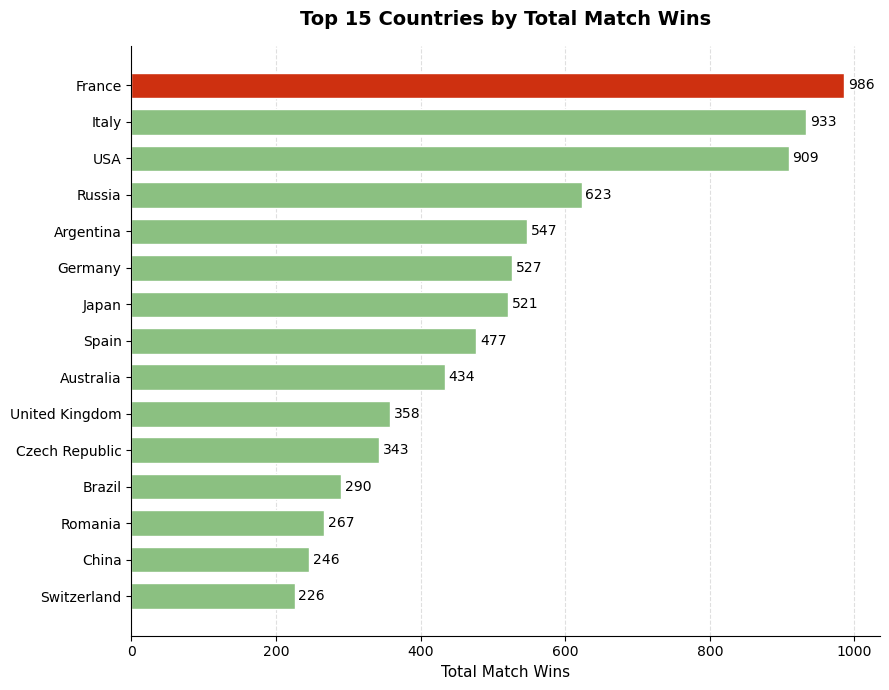

In [6]:
# Visualization
top = country_wins.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#8BC081"] * (len(top) - 1) + ["#CE3010"]
bars = ax.barh(top.index, top.values, color=colors, edgecolor='white', height=0.7)
for bar, v in zip(bars, top.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, f'{int(v)}', va='center', fontsize=10)
ax.set_xlabel('Total Match Wins', fontsize=11)
ax.set_title('Top 15 Countries by Total Match Wins', fontsize=14, fontweight='bold', pad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.savefig('charts\q6_country_wins.png', dpi=200, bbox_inches='tight')

Observation: By total wins: France (986), Italy (933), USA (909). With ≥50 players, wins per player: Argentina (5.58), Brazil (5.00), France (4.88), Spain (4.87), Czech Republic (4.83).

Interpretation: At the 50-player threshold, total-wins and wins-per-player leaders overlap more than at a low threshold. The answer depends on definition (volume vs rate) and on the player-count cutoff.

Limitation: "Most successful" is being operationalized two different ways in this notebook (total wins vs. wins per player) — the answer depends on which definition is used and where the player-count cutoff is set, not on a single fixed fact.